Importing the Dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

Data Collection and Processing

In [2]:
#loading the data from csv file to pandas data frame
car_dataset=pd.read_csv(r'C:\Users\LENOVO\Desktop\Car Price Prediction\Car details v3.csv')

In [3]:
# car_dataset=tables[0]

In [4]:
# car_dataset.to_csv(r'C:\Users\LENOVO\Desktop\Car Price Prediction\car_data_set.csv'index=False)

In [5]:
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
#inspecting the first 5 rows in data set
print(car_dataset.head())

                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner     mileage   engine   max_power  \
0  Individual       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1  Individual       Manual  Second Owner  21.14 kmpl  1498 CC  103.52 bhp   
2  Individual       Manual   Third Owner   17.7 kmpl  1497 CC      78 bhp   
3  Individual       Manual   First Owner   23.0 kmpl  1396 CC      90 bhp   
4  Individual       Manual   First Owner   16.1 kmpl  1298 CC    88.2 bhp   

                     torque  seats  
0            190Nm@ 2000rpm    5.0  
1       250N

In [7]:
# checking the number of rows and columns

car_dataset.shape

(8128, 13)

In [8]:
#getting some information about the data frame
car_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [9]:
#checking the number of missing values
car_dataset.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [10]:
#checking the distribution of categorical data
print(car_dataset['fuel'].value_counts())
print(car_dataset['seller_type'].value_counts())
print(car_dataset['transmission'].value_counts())


fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64


Encoding the categorical Data

In [11]:
#encoding 'Fuel_Type' column
car_dataset.replace({'fuel':{'Diesel':0,'Petrol':1,'CNG':2,'LPG':3}},inplace=True)

#encoding 'Seller_type' column
car_dataset.replace({'seller_type':{'Individual':0,'Dealer':1,'Trustmark Dealer':2}},inplace=True)

#encoding 'transmission' column
car_dataset.replace({'transmission':{'Manual':0,'Automatic':1}},inplace=True)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,0,0,0,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,0,0,0,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,1,0,0,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,0,0,0,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,1,0,0,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,1,0,0,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,0,0,0,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,0,0,0,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,0,0,0,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [12]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,0,0,0,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,0,0,0,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,1,0,0,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,0,0,0,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,1,0,0,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [13]:
# Step 1: Check where the NaN values are
print(car_dataset.isnull().sum())
print("Total NaN values:", car_dataset.isnull().sum().sum())

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64
Total NaN values: 1100


In [14]:
# See NaN count per column
print(car_dataset.isnull().sum())
print("\nDataset shape:", car_dataset.shape)

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Dataset shape: (8128, 13)


In [15]:
# Full diagnosis in one block
print("=== Column Names ===")
print(car_dataset.columns.tolist())

print("\n=== NaN per Column ===")
print(car_dataset.isnull().sum())

print("\n=== Data Types ===")
print(car_dataset.dtypes)

print("\n=== Sample Data ===")
print(car_dataset.head(3))

=== Column Names ===
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']

=== NaN per Column ===
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

=== Data Types ===
name                 str
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner                str
mileage              str
engine               str
max_power            str
torque               str
seats            float64
dtype: object

=== Sample Data ===
                           name  year  selling_price  km_driven fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500    0 

In [16]:
car_dataset['mileage'] = car_dataset['mileage'].str.extract(r'([\d.]+)').astype(float)
car_dataset['engine'] = car_dataset['engine'].str.extract(r'([\d.]+)').astype(float)
car_dataset['max_power'] = car_dataset['max_power'].str.extract(r'([\d.]+)').astype(float)


In [17]:
car_dataset.drop(columns=['torque'], inplace=True)


In [18]:
car_dataset.replace({'owner': {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}}, inplace=True)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,0,0,0,1,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,0,0,0,2,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,1,0,0,3,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,0,0,0,1,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,1,0,0,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,1,0,0,1,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,0,0,0,4,16.80,1493.0,110.00,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,0,0,0,1,19.30,1248.0,73.90,5.0
8126,Tata Indigo CR4,2013,290000,25000,0,0,0,1,23.57,1396.0,70.00,5.0


In [19]:
car_dataset.dropna(inplace=True)


In [20]:
print("NaN values remaining:", car_dataset.isnull().sum().sum())
print("Final shape:", car_dataset.shape)
print(car_dataset.dtypes)

NaN values remaining: 0
Final shape: (7906, 12)
name                 str
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
dtype: object


In [21]:
print(car_dataset.isnull().sum())
print("Total NaN values:", car_dataset.isnull().sum().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64
Total NaN values: 0


Splitting the data and Target

In [22]:
X=car_dataset.drop(['name','selling_price'],axis=1)
Y=car_dataset['selling_price']


In [23]:
print(X)

      year  km_driven fuel seller_type transmission owner  mileage  engine  \
0     2014     145500    0           0            0     1    23.40  1248.0   
1     2014     120000    0           0            0     2    21.14  1498.0   
2     2006     140000    1           0            0     3    17.70  1497.0   
3     2010     127000    0           0            0     1    23.00  1396.0   
4     2007     120000    1           0            0     1    16.10  1298.0   
...    ...        ...  ...         ...          ...   ...      ...     ...   
8123  2013     110000    1           0            0     1    18.50  1197.0   
8124  2007     119000    0           0            0     4    16.80  1493.0   
8125  2009     120000    0           0            0     1    19.30  1248.0   
8126  2013      25000    0           0            0     1    23.57  1396.0   
8127  2013      25000    0           0            0     1    23.57  1396.0   

      max_power  seats  
0         74.00    5.0  
1        103.

In [24]:
print(Y)

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8123    320000
8124    135000
8125    382000
8126    290000
8127    290000
Name: selling_price, Length: 7906, dtype: int64


Splitting Training and test data

In [25]:
X_train,X_test,Y_train,y_test=train_test_split(X,Y,test_size=0.1, random_state=2)

Model Training

1.linear regression

In [26]:
1 #loading the linear regression model
linear_regression_model=LinearRegression()

In [27]:
linear_regression_model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
# print(car_dataset.columns.tolist())

Model Evaluation

In [30]:
#prediction on Training data
training_data_prediction=linear_regression_model.predict(X_train)

In [31]:
#R squared error
error_score=metrics.r2_score(Y_train,training_data_prediction)
print("R squared Error :", error_score)

R squared Error : 0.6693523223917119


Visualize the actual prices and predicted prices


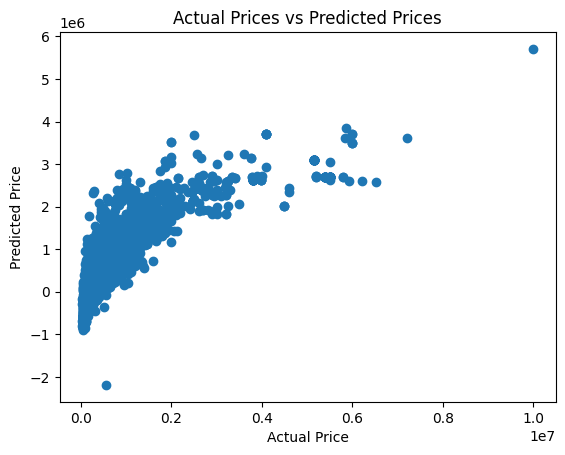

In [32]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [35]:
#prediction on Training data
test_data_prediction=linear_regression_model.predict(X_test)

In [36]:
#R squared error
error_score=metrics.r2_score(y_test,test_data_prediction)
print("R squared Error :", error_score)

R squared Error : 0.6769030459461315


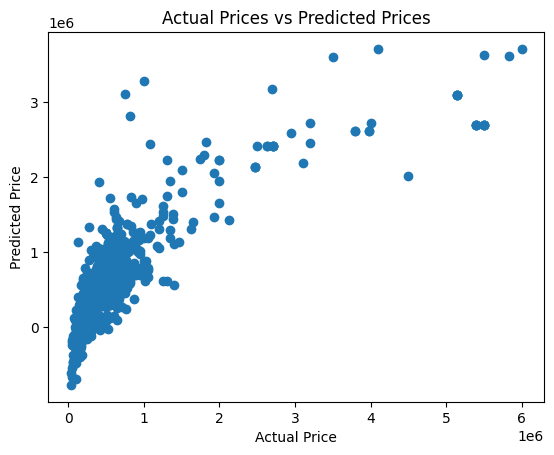

In [37]:
plt.scatter(y_test,test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

Lasso Regression

In [38]:
1 #loading the linear regression model
lasso_regression_model=Lasso()

In [39]:
lasso_regression_model.fit(X_train,Y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [ ]:
# print(car_dataset.columns.tolist())

Model Evaluation

In [40]:
#prediction on Training data
training_data_prediction=lasso_regression_model.predict(X_train)

In [41]:
#R squared error
error_score=metrics.r2_score(Y_train,training_data_prediction)
print("R squared Error :", error_score)

R squared Error : 0.6693523223506326


Visualize the actual prices and predicted prices

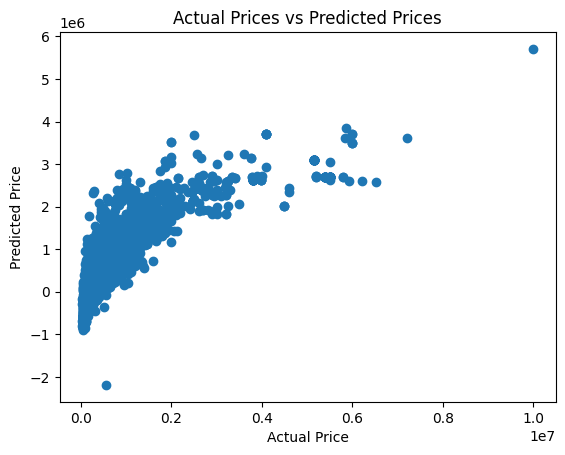

In [42]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [43]:
#prediction on Training data
test_data_prediction=lasso_regression_model.predict(X_test)

In [44]:
#R squared error
error_score=metrics.r2_score(y_test,test_data_prediction)
print("R squared Error :", error_score)

R squared Error : 0.6769024335997951


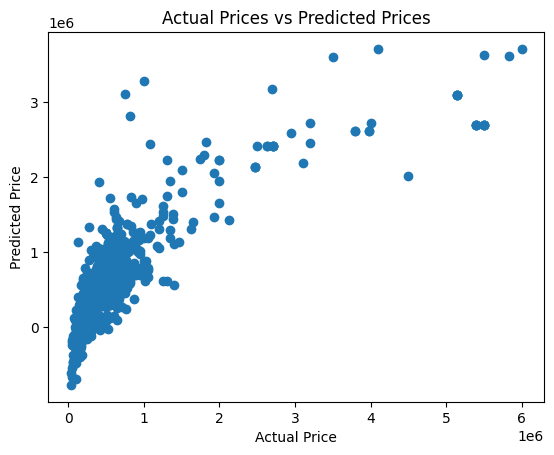

In [45]:
plt.scatter(y_test,test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()